# <u>Project 6 - Code Breaking with Statistical Physics

##### __Authors:__ Alex Bell, Lucy Burchell, Hong Chen, Bingxiang Hu, Zoe Morton.

# Table of Contents
* [Introduction](#intro)
* [Preliminaries](#pres)
* [Section1: Simple Cyclic Shifts](#s1)
* [Section2: Working with Frequencies](#s2)
  * [2.1: Further Work with Frequencies](#s2.1)
* [Section3: Applying Statistical Physics](#s3)
  * [3.1: The Metropolis Algorithm](#s3.1)
* [Section4: Improvements and Analysis](#s4)
  * [4.1: Adapting the Metropolis Algorithm](#s4.1)
    * [4.1.1 Trigrams](#subsec4.1.1)
    * [4.1.2 Word Analysis](#subsec4.1.2)
    * [4.1.3 Different Languages](#subsec4.1.3)
  * [4.2: Frequency Analysis Adjustment](#s4.2)
  * [4.3: Using Graphical Representations](#s4.3)
* [Results](#results)
* [Conclusion](#con)
* [Bibliography](#bib)

<a id="intro"></a>
## <u>Introduction

National security, personal privacy and QR codes on the products (1) we buy are some examples of how code breaking is used everyday. In this project, we explore potential methods used to decrypt coded messages with a particular focus on statistical physics. We aim to analyse the effectiveness of these methods by attempting to decrypt twelve encrypted messages, of which have varying difficulty, thus requiring different deciphering methods. 

<a name="pres"></a>
## <u>Preliminaries

Run the cell below to import the necessary libraries before continuing with this notebook.

In [1]:
import nbformat
import requests
import re
%run get_coded_message.ipynb         # Creates a path to easily reference our coded messages
import math
import random
from collections import Counter
import matplotlib.pyplot as plt
!pip install translate

LOJ WUZCWKCTFHHFHTWUZFHQWMZEUW EAWKCWUZCWCHV
  Using cached translate-3.8.0-py2.py3-none-any.whl.metadata (9.1 kB)
  Using cached libretranslatepy-2.1.1-py3-none-any.whl.metadata (233 bytes)
Using cached translate-3.8.0-py2.py3-none-any.whl (14 kB)
Using cached libretranslatepy-2.1.1-py3-none-any.whl (3.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [translate]


<a name="s1"></a><u>
## Section One: Simple Cyclic Shifts

In this section, we introduce a simple cyclic shift applied to a set of 27 characters (the Latin alphabet plus the 'space' character). We will continue to use this throughout the project and store these characters in a list. 

By defining a new function to receive this list, and apply a cyclic shift of a variable number, so we can easily map each letter to its shifted character.

As an example, we will apply this cyclic shift function to our first coded message to decode it.

#### Coded Message:

> 1\. GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ

#### Method:

Our initial thought was to identify the most frequent character within the coded message, assuming this must be the ciphered 'space' character. By using a search function, we determined this to be 'R'.

From here, we calculated the cyclic shift (from the coded message to our character list) and translated our method into Python:

In [2]:
# Check the correct coded message was recieved
print(get_coded_message(0))

GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ


In [3]:
# Define our list of 27 characters that we will continue to use throughout the project
character_list = ["A" , "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", 
                  "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z", " "]

In [4]:
# Define the cyclic shift function
shift = 9

def cyclic_shift(cipher_letter):
    
    cipher_index = character_list.index(cipher_letter)   # Run through each letter in the list
    character_index = (cipher_index + shift) % 27        # Perform the shift on the index (allowing the list to loop)
    
    decipher_letter = character_list[character_index]    # Apply the shift to receive the new character from our list

    return decipher_letter

In [5]:
# Test the function works
cyclic_shift('R')

' '

In [6]:
# For completeness, here is a list of all the cyclic shifts for this particular message:
for letter in character_list:
    print(f'{letter} --> {cyclic_shift(letter)}')

A --> J
B --> K
C --> L
D --> M
E --> N
F --> O
G --> P
H --> Q
I --> R
J --> S
K --> T
L --> U
M --> V
N --> W
O --> X
P --> Y
Q --> Z
R -->  
S --> A
T --> B
U --> C
V --> D
W --> E
X --> F
Y --> G
Z --> H
  --> I


In [7]:
# Define a decoding function
def message_decoder(coded_message):

    deciphered_message = ''

    for i in range(0, len(coded_message),):
        
        current_letter = coded_message[i]                 # Takes individual coded letter from the full coded message

        deciphered_letter = cyclic_shift(current_letter)  # Applies the clyclic shift to each letter

        deciphered_message += deciphered_letter           # Adds these decoded letters to our deciphered messsage

    return deciphered_message                             # Returns the fully decoded message

In [8]:
# Apply this function to our first coded message
message_decoder(get_coded_message(0))

'PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS'

##### Below is the fully decoded message (written with correct punctuation):

>Python is an interpreted, high level, and general purpose programming language. Python's design philosophy EMP hasizes code readability with it's notable use of significant indentation. Its language constructs and object-oriented approach aim to help programmers write clear, logical code for small and large-scale projects.

## <a name="s2"></a> <u>Section Two: Working with Frequencies

Whilst section one shows that an encrypted message built using simple cyclic shifts can be decoded "by hand", other encrytions that use arbitrary permutations make the above method impractical. Therefore, we will explore how we could instead use certain statistics of the coded messages. The idea is to permute the characters in our message to a corresponding character in our alphabet and space list based upon the frequencies. We can then track whether the readability of the message increases/improves as we complete these shifts.

To do this we need to know two things: the frequencies of the 27 characters generally in the English language and the frequencies of the 27 characters in the coded message.

The frequencies of the 27 characters in the English language can be approximated by the frequencies in a large body of English text, for example Moby-dick by Herman Melville (2). We are only interested in the characters in our list so we must remove all punctuation from the text and capitalise all of the letters. Note, it is also important that the number of spaces does not change during this transformation of the Moby-dick text, as a space is one of the 27 characters. 

#### To import the Moby_dick text:

In [9]:
# THIS CELL ONLY NEEDS TO BE RUN ONCE
# Goes to the URL below and writes the contents of the book Moby-dick to a file called moby.txt
# Then saves the text to a list
url = "http://www.gutenberg.org/files/2701/2701-0.txt"
moby = requests.get(url).text
def get_text(url,file_name):
    file = requests.get(url).text

    try:                           
        f = open(file_name,"x")   # Creates the file the first time
    except FileExistsError:       # But is skipped if the file already exists
        pass
    
        
    with open(file_name,"w",errors = "ignore") as f:
        f.write(file)  # Write to file
    with open(file_name,"r",errors = "ignore") as f:
        file = f.read()  # Read from file
    
    # We want to make all the letters upper case
    file = file.upper()
    # Then we remove anything that isn't an upper case letter, a new line, or a space
    file = re.sub(r'[^A-Z\s]', ' ', file)
    # and then remove any additional spaces that weren't in the original text
    file = re.sub(r' +', ' ', file)
    # Finally remove any newlines and replaces them with spaces
    file = re.sub(r'\n', ' ', file)
    file = re.sub(r'\xa0', ' ', file)

    return file

moby_new = get_text(url, "moby.txt")

#### Exploring Frequencies:

We can find the frequencies of the 27 charcters for any imported text, for example for our large smaple text.

In [10]:
# Count the number of each character that appears in our imported text
for i in range(27):
    frequency = moby_new.count(character_list[i])
    print(character_list[i], frequency)

A 78224
B 16936
C 22718
D 38311
E 117511
F 20880
G 20875
H 63239
I 65586
J 1088
K 8087
L 42875
M 23325
N 65760
O 69457
P 17443
Q 1570
R 52419
S 64390
T 88391
U 26697
V 8614
W 22264
X 1036
Y 16899
Z 634
  228388


We can interact/test this method will work for other texts using a random string of text:

In [11]:
# Testing Cell to interact with the frequencies of different texts
# We can build a list of 100 random characters (we can change the length)
random_chars= [random.choice(character_list) for _ in range(100)]
# Then we can build a string of random characters to then test the frequency operation above
random_text= "".join(random_chars)
print(random_text)
# Count the number of each character that appears in our random text
for i in range(27):
    frequency = random_text.count(character_list[i])
    print(character_list[i], frequency)

KKDNEYPRQIEXAF YGORVKPIEKQMBMIHGOQNMJTLPTQFE RDUIHUFINYCZMIDIJNNWZGWMZQLXBPFVIHTCMXTL TZVYFPPYKVNKXY
A 1
B 2
C 2
D 3
E 4
F 5
G 3
H 3
I 8
J 2
K 6
L 3
M 6
N 6
O 2
P 6
Q 5
R 3
S 0
T 5
U 2
V 4
W 2
X 4
Y 6
Z 4
  3


Now that we have our large English text prepared and are satisfied that the frequency method works for any text random or not, we can find the frequency of each of the 27 characters and then sort them. We can then repeat for any of the coded messages. 

To do so, we define a get_frequency function that returns a list of tuples where the first entry is the character and the second is the frequency, relative to the total, sorted from most common/frequent to least.

In Python this translates to the following code:

In [12]:
# ALL ENCODED TEXT IS ASSUMED TO BE UPPERCASE

# Defining a new function that takes in a string (could be a large example of English or a specific encoded piece of text)
def get_frequency(text):
    length = len(text)
    frequency = []

    for char in character_list:
        # To calculate the fraction of the text each letter makes up
        if char == " ":
            frequency.append((char,(text.count(char)+text.count("\n"))/length))    
            
        else:
            frequency.append((char,text.count(char)/length))
            
    # Returns a list containing tuples of each letter and its frequency, sorted by frequency
    return sorted(frequency, key = lambda x: x[1])[::-1]    # Sorts the list by the second entry in each tuple and then reverses it

Now we want to use our knowledge of the character frequencies to decipher the coded message. 

First we define a function that for a coded message will return what each of the characters should map to, based upon their position in the "most to least frequent" list. This is a letter mapping.

In [13]:
# Defining a new function that takes in an encoded string and list containing tuples of each letter and its frequency, sorted by frequency (can be found from get_frequency)
def get_letter_map_from_frequency(ciphertext,english_frequencies,verbose = False):
    out = {}
    text_freq = get_frequency(ciphertext)
    print("The frequencies in the text are: \n")
    if verbose:
        for pair in text_freq:
            print(f"{pair[0]}: {pair[1]}")
    for i in range(len(text_freq)):
        encoded_letter = text_freq[i][0]
        english_letter = english_frequencies[i][0]

        out[encoded_letter] = english_letter
    # Returns a dictionary mapping the most common letters in the encoded string with the most common letters in English
    return out

We need a function that for each character in the coded message returns the character it represents according to a letter mapping. Thus if the input is a string of multiple characters, the output will be a new string of equal characters where the map has been applied.

In [14]:
# Defining a new function that takes in a string to be decoded and a dictionary with the encoded letters as keys and their respective decoded letters as values
def decode(ciphertext,letter_map):
    out = ""
    for char in ciphertext:
        if char != "\n":
            out += letter_map[char]
        else:
            out += letter_map[" "]
    # Returns a decoded string
    return out

As an example we can apply our work to the second coded message:

#### Coded Message:

>2\. RECFV KUWE VJCRWQFCRCFICYWEZRWKLVJWQF SCRRZ ALVWJLAACFWNATZVW NFWIZRZT FWELYWVCSTWNRWLVTE NBEWZTWHLRWCLRMWS FWJCWHE WUACHWEZJWR WHCVVWT WRCCWTELTWECWHLRWQF S NAYVMWCPKZTCYWTECWJ JCATWTELTWEZVT AWKNGZTTWRWGF LYWGLKUWELYWYZRLQQCLFCYWTEF NBEWTECWY FWJMWK JFLYCWFNRECYWT WTECWTLGVCWVLZYW NTWLVVWTECWRVZQRW SWQLQCFWK ATLZAZABWYLAKZABWJCAWZAWSF ATW SWEZJWLAYWTEFCHWEZJRCVSWZAT WLAWZATFZKLTCWLAYWCVLG FLTCWKLVKNVLTZ AWS FWTH WE NFRWZWHLTKECYWEZJWLRWECWK ICFCYWRECCTWLSTCFWRECCTW SWQLQCFWHZTEWSZBNFCRWLAYWVCTTCFRWR WK JQVCTCVMWLGR FGCYWZAWEZRWTLRUWTELTWECWELYWCIZYCATVMWS FB TTCAWJMWQFCRCAKCWR JCTZJCRWECWHLRWJLUZABWQF BFCRRWLAYWHEZRTVCYWLAYWRLABWLTWEZRWH FUWR JCTZJCRWECWHLRWQNDDVCYWLAYWH NVYWRZTWS FWV ABWRQCVVRWHZTEWLWSNFF HCYWGF HWLAYWLWILKLATWCMCWSZALVVMWECWRQFLABWSF JWEZRWKELZFWHZTEWLWKFMW SWRLTZRSLKTZ AWLAYWHLVUCYWNQWLAYWY HAWTECWF JWFNGGZABWEZRWELAYRWT BCTECFWTECAWECWHF TCWLWV ABWTCVCBFLJWNQ AWLWKLGVCWS FJWZSWJMWLARHCFWT WTEZRWZRWLRWZWE QCWM NWHZVVWELICWLWICFMWQFCTTMWKLRCWT WLYYWT WM NFWK VVCKTZ AWHLTR AWRLZYWECWZWCPQCKTWTELTWHCWRELVVWGCWLGVCWT WB WY HAWT WA FS VUWT J FF HWLAYWT WTLUCW NFWSFZCAYWR JCWICFMWYCSZAZTCWACHRWLRWT WTECWRCKFCTW SWEZRWLAA MLAKCWZWK ASCRRWTELTWZWHLRWSZVVCYWHZTEWKNFZ RZTMWGNTWZWHLRWLHLFCWTELTWE VJCRWVZUCYWT WJLUCWEZRWYZRKV RNFCRWLTWEZRW HAWTZJCWLAYWZAWEZRW HAWHLMWR WZWHLZTCYWNATZVWZTWRE NVYWRNZTWEZJWT WTLUCWJCWZAT WEZRWK ASZYCAKCWGNTWTECFCWHLRWLWYCVLMWZAWTELTWLARHCFZABWTCVCBFLJWLAYWTH WYLMRW SWZJQLTZCAKCWS VV HCYWYNFZABWHEZKEWE VJCRWQFZKUCYWNQWEZRWCLFRWLTWCICFMWFZABW SWTECWGCVVW AWTECWCICAZABW SWTECWRCK AYWTECFCWKLJCWLWVCTTCFWSF JWEZVT AWKNGZTTWLVVWHLRWXNZCTWHZTEWEZJWRLICWTELTWLWV ABWZARKFZQTZ AWELYWLQQCLFCYWTELTWJ FAZABWNQ AWTECWQCYCRTLVW SWTECWRNAYZLVWECWZAKV RCYWLWK QMW SWZTWHEZKEWZRWECFCWFCQF YNKCYWCVRZCWQFCQLFCWT WJCCTWTEMWB YWE VJCRWGCATW ICFWTEZRWBF TCRXNCWSFZCDCWS FWR JCWJZANTCRWLAYWTECAWRNYYCAVMWRQFLABWT WEZRWSCCTWHZTEWLAWCPKVLJLTZ AW SWRNFQFZRCWLAYWYZRJLMWEZRWSLKCWHLRWELBBLFYWHZTEWLAPZCTM

In [15]:
# Assign our coded message to a variable (so it could easily be changed in the future)
ciphertext = get_coded_message(1)
moby_clean = moby_new

print(f'The length of our coded message is: {len(ciphertext)}\n')

# Decode the message using the frequencies
english_frequencies = get_frequency(moby_new)
letter_map = get_letter_map_from_frequency(ciphertext,english_frequencies)
output = decode(ciphertext,letter_map)
print(output)

print(f'\nThe length of our output message is: {len(output)}')   # Should be the same as the coded message length

The length of our coded message is: 1944

The frequencies in the text are: 

ISERLOCV SOLMEI GREIERKED SNI CALM GROWEIINOHAL MAHHER FHTNL OFR KNINTOR SAD LEWT FI ALTSOFPS NT UAI EAIB WOR ME USO VHEU SNM IO UELL TO IEE TSAT SE UAI GROWOFHDLB EQCNTED TSE MOMEHT TSAT SNLTOH CFYNTT I YROAD YACV SAD DNIAGGEARED TSROFPS TSE DOR MB COMRADE RFISED TO TSE TAYLE LAND OFT ALL TSE ILNGI OW GAGER COHTANHNHP DAHCNHP MEH NH WROHT OW SNM AHD TSREU SNMIELW NHTO AH NHTRNCATE AHD ELAYORATE CALCFLATNOH WOR TUO SOFRI N UATCSED SNM AI SE COKERED ISEET AWTER ISEET OW GAGER UNTS WNPFREI AHD LETTERI IO COMGLETELB AYIORYED NH SNI TAIV TSAT SE SAD EKNDEHTLB WORPOTTEH MB GREIEHCE IOMETNMEI SE UAI MAVNHP GROPREII AHD USNITLED AHD IAHP AT SNI UORV IOMETNMEI SE UAI GFJJLED AHD UOFLD INT WOR LOHP IGELLI UNTS A WFRROUED YROU AHD A KACAHT EBE WNHALLB SE IGRAHP WROM SNI CSANR UNTS A CRB OW IATNIWACTNOH AHD UALVED FG AHD DOUH TSE ROM RFYYNHP SNI SAHDI TOPETSER TSEH SE UROTE A LOHP TELEPRAM FGOH A CAYLE WORM NW MB AHIUER 

<a id="s2.1"></a>
#### Working to improve our resulting messages further:

To further improve our decrypted string of characters, we can manually swap two characters in a partially solved messages from the work above and then see if readability increases/improves.

In Python, the following code achieves this idea:

In [16]:
# We want a function that swaps all of one character with another, both are specified as the variables of the function
def swap_of_char(string, char_1, char_2):
    # If both letters are the same, the string will be as it originally was
    if char_1 == char_2: 
        return string
    else:
        # Using a temporary character $ to replce all of char_1
        string = string.replace(char_1, "$")
        # Replacing all of char_2 with char_1
        string = string.replace(char_2,char_1)
        # Finally replacing all of temporary character $ with char_2
        string = string.replace("$", char_2)
    return string

Our initial message is the result of the frequency letter mapping and permutations in the previous function. 

Then, using our knowledge of English words, we spotted potential swaps that would make the coded message incrementally closer to English. To begin we chose two random characters to swap, analysed what change occured and by inspection chose a suitable next swap to be "W" and "F". We repeated this and more words were readable. 

Our final swap was focused on the part of the string which printed "FRIEJE". We could not inspect what the deciphered word was meant to be. Therefore, we researched this extract of what we found to be "The Adventure of the Dancing Men" (3) to find the word was meant to be "frieze" once fully decoded- justifying our final swap of "J" and "Z".

In [17]:
# After seeing how this swap has effected the code, you can adjust the cipher by hand:
output = decode(ciphertext,letter_map)
output = swap_of_char(output, "P", "G")
output = swap_of_char(output, "W", "F")
output = swap_of_char(output, "I", "H")
output = swap_of_char(output, "S", "H")
output = swap_of_char(output, "I", "N")
output = swap_of_char(output, "V", "K")
output = swap_of_char(output, "W", "U")
output = swap_of_char(output, "B", "Y")
output = swap_of_char(output, "Q", "X")
swap_of_char(output, "J", "Z")

'SHERLOCK HOLMES PRESERVED HIS CALM PROFESSIONAL MANNER UNTIL OUR VISITOR HAD LEFT US ALTHOUGH IT WAS EASY FOR ME WHO KNEW HIM SO WELL TO SEE THAT HE WAS PROFOUNDLY EXCITED THE MOMENT THAT HILTON CUBITT S BROAD BACK HAD DISAPPEARED THROUGH THE DOR MY COMRADE RUSHED TO THE TABLE LAID OUT ALL THE SLIPS OF PAPER CONTAINING DANCING MEN IN FRONT OF HIM AND THREW HIMSELF INTO AN INTRICATE AND ELABORATE CALCULATION FOR TWO HOURS I WATCHED HIM AS HE COVERED SHEET AFTER SHEET OF PAPER WITH FIGURES AND LETTERS SO COMPLETELY ABSORBED IN HIS TASK THAT HE HAD EVIDENTLY FORGOTTEN MY PRESENCE SOMETIMES HE WAS MAKING PROGRESS AND WHISTLED AND SANG AT HIS WORK SOMETIMES HE WAS PUZZLED AND WOULD SIT FOR LONG SPELLS WITH A FURROWED BROW AND A VACANT EYE FINALLY HE SPRANG FROM HIS CHAIR WITH A CRY OF SATISFACTION AND WALKED UP AND DOWN THE ROM RUBBING HIS HANDS TOGETHER THEN HE WROTE A LONG TELEGRAM UPON A CABLE FORM IF MY ANSWER TO THIS IS AS I HOPE YOU WILL HAVE A VERY PRETTY CASE TO ADD TO YOUR COLLECT

The fully decoded message (with correct punctuation):
>Sherlock Holmes preserved his calm professional manner until our visitor had left us, although it was easy for me, who knew him so well, to see that he was profoundly excited. The moment that Hilton Cubitt’s broad back had disappeared through the door my comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation. For two hours I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and whistled and sang at his work. Sometimes he was puzzled, and would sit for long spells with a furrowed brow and a vacant eye. Finally he sprang from his chair with a cry of satisfaction, and walked up and down the room rubbing his hands together Then he wrote a long telegram upon a cable form. “If my answer to this is as I hope, you will have a very pretty case to add to your collection, Watson,” said he. “I expect that we shall be able to go down to Norfolk to-morrow, and to take our friend some very definite news as to the secret of his annoyance. I confess that I was filled with curiosity, but I was aware that Holmes liked to make his disclosures at his own time and in his own way, so I waited until it should suit him to take me into his confidence. But there was a delay in that answering telegram, and two days of impatience followed, during which Holmes pricked up his ears at every ring of the bell. On the evening of the second there came a letter from Hilton Cubitt. All was quiet with him, save that a long inscription had appeared that morning upon the pedestal of the sun-dial. He inclosed a copy of it, which is here reproduced, Holmes bent over this grotesque frieze for some minutes, and then suddenly sprang to his feet with an exclamation of surprise and dismay. His face was haggard with anxiety.

<a id="s3"></a>
## <u>Section Three: Applying Statistical Physics

Whilst our work so far can decipher longer messages, where we have enough information about the frequencies of the characters to compare to their general frequencies in the English Language, shorter or non-English messages require statistical physics. 

Statistical Physics (4), in the context of this cryptography project, uses ideas from probability and statistics of individual characters to understand properties of the large overall string of text.  

One statistic we can work with in particular is the Score, which is a quantitative indication of how "English" a piece of text is. 

In order to calculate this, we need to know how likely in the English language it is to see the pairs of characters that the coded message has. 

Thus we need to find the frequency of:
* Each of the $27$ characters,
* Each of the $27^2$ bigrams (pairs of consecutive characters).

In [18]:
## Logic and knowledge of the English language tells us certian pairs of letters, for example: 'wj', have zero frequency whereas others such as 'ee' are more frequent

def all_bigram_freqs(string,character_list):
    # Defining the dictionary of frequencies
    single_frequencies = {}
    bi_frequencies = {}

    # Sets the values for each letter and bigram as 1    
    for char_1 in character_list:
        single_frequencies[char_1] = 0
        
        for char_2 in character_list:
            pair = char_1 + char_2
            bi_frequencies[pair]= 0

    # Iterates through the text, updating the single and bigram dictionaries for the current letter and bigram
    for i in range(len(string)-1):
        single_frequencies[string[i]] += 1
        bi_frequencies[string[i:i+2]] += 1
        
    return single_frequencies , bi_frequencies
    
# Note index [0] will give the single frequencies dictionary and index [1] will give the bigram frequencies


Then, for each pair of characters $i, j$, we want to compute the probability that $i$ is followed by $j$.

$$p(i, j) := \frac{\text{frequency}(ij) + 1}{\text{frequency}(i)}$$

*(Note: We include a $+1$, the 'fudge factor', to avoid zeros).*

In Python, we can define this formula as a function as follows:

In [19]:
# Now we want to define a function that, for a pair of characters, finds the probability that the first letter is followed by the second letter in the piece of text

def proportion(char_1, char_2, all_bigram_freqs_dicts):
    x = all_bigram_freqs_dicts
    pair = char_1 + char_2
    p = (x[1][pair] + 1 )/(x[0][char_1])
    return p

For any potential decoded message $m = i_1i_2\dots i_n$, we assign a score $S(m)$ which measures its plausibility as English text:

$$S(m) = \sum_{j=1}^{n-1} \log p(i_j, i_{j+1})$$

In Python, we can define a function that calculates the Score for any of our coded messages:

In [20]:
# The score function S(m) can be defined as:
def score(string,all_bigram_freq_dicts):
    
    n = len(string)    # Where n is the total number of characters in the string
    total_log_ps = 0
    
    for j in range(1, n-1):
        
        # Index the string of text to find the jth and (j+1)th letter
        p_j = proportion(string[j], string[j+1],all_bigram_freq_dicts)
        total_log_ps += math.log(p_j)

    return total_log_ps

<a id="s3.1"></a>
#### Making use of our Score statistic - The Metropolis Algorithm

In order to make a decision whether the current state of the encrypted message is "better" or "closer to english" than a partially decoded version of the same message, we can apply the Metropolis Algorithm. 

(For an interested reader: the main idea around The Metropolis Algorithm (5) is sampling under a claim or a proposed distribution over many iterations in order to find out information about the invariant distribution, of which the samples actually come from. This invariant distribution is the result in mind when using the algorithm. To get there, the algorithm converges as (in theory) the number of iterations tends to infinity. Interestingly, the distributions you work with to understand more about the invariant one depend upon their previous values, i.e the sample drawn next time will depend on the sample just drawn)

We start by calculating the Score of the decrypted message or an initial guess- this is $S(m)$.

Using our swap of characters function, we produce a new message $m'$ by following the process of choosing two characters, applying the swap function, inspecting the change and repeating a sufficient number of times. Then we calculate the Score of this new message- this is $S(m')$.

Then we compare our two statistics.

If $S(m') > S(m)$ then we will replace $m$ with $m'$. 

On the other hand, if $S(m') \leq S(m)$ then replace $m$ with $m'$ with probability:

$$p= \exp \frac{S(m') - S(m)}{T}$$

otherwise just keep $m$. 

We can repeat this for many steps (e.g. 100000) for different starting messages and adjusting the parameters. $T$ is the temperature, which measures the algorithms likelihood of accepting a worse message (with a lower Score).

First we try $T = 1$.

#### Coded Message:

> 3\. TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK

In [21]:
# Reassigning this same coded message for a smoother reference
message = get_coded_message(2)

# Check the correct coded message was recieved
print(f'Our third coded message:\n\n{message}')

Our third coded message:

TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK


In [22]:
# Construct a dictionary of the frequency of every letter and every possible bigram in a sample text
all_bigram_freqs_dicts = all_bigram_freqs(moby_new,character_list)

# Form an algorithm to decode a piece of encoded English text:
    ## Take in a ciphertext, a list of all characters present (in caps), a sample frequency dictionary of bigrams and letters, the number of iterations
    ## to run for (let's call this N), the temperature used in the algorithm (T) and a verbose keyword argument which prints the current partially decoded 
    ## text in at certain steps - then return the decoded text
def metropolis(ciphertext, character_list, all_bigram_freqs_dicts, N, T, verbose = False, simulated_annealing = False):
    n = len(character_list)
    current_string = ciphertext

    T_0 = T

    # For Section Four, we need to record the history of the score after each step:
    score_history = []
    
    # We now need to iterate N times, switching two random letters to create a candidate message, and then take the candidate message according to
    # probabilities defined by the Metropolis Algorothim (based on the Boltzmann Distribution)
    for i in range(N):
        letter_1 = character_list[random.randrange(n)]
        letter_2 = character_list[random.randrange(n)]
        potential_string = swap_of_char(current_string,letter_1,letter_2)
        
        s_current = score(current_string,all_bigram_freqs_dicts)
        s_potential = score(potential_string,all_bigram_freqs_dicts)

        if s_potential > s_current:
            current_string = potential_string
        else:
            r = random.random()
            val = math.exp((s_potential - s_current)/T) # Here T is prop. to the probability - we take a backwards step in the hopes it later improves the text
            if r <= val:
                current_string = potential_string

        # Updating our history record
        score_history.append(s_current)

        # If verbose, we print the current string every 10% through N we get
        if verbose:
            if i%(N/10) == 0:
                print(current_string)
                print()

        # If simulated annealing, linearly decrease the T each step (with a slight fudge factor to avoid 0)
        if simulated_annealing:
            T = (N-i+1)*T_0/N


    return current_string, score_history


final_text, score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = True)
print(final_text)

TALOMREMUEKBLRSWCTMWBIHB BTN KKAT NBTALOMRB DWBKSYMBYSWMRDBTALOMRKBJANNBRMQM NBKE EAKEAT NBADPSRY EASDB ISCEBEOMBLN ADEMUEB DWBEO EBADPSRY EASDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTALOMRB PEMRBEOMBWAKTSQMRHBSPBPRMVCMDTHB D NHKAKBIHBEOMB R IBY EOMY EATA DB DWBLSNHY EOB NBXADWAB NKSBXDSJDB KB NXADWCKBADBEOMBDADEOBTMDECRHBDM RNHB NNBKCTOBTALOMRKBTSCNWBIMBIRSXMDBIHB DBADPSRYMWB EE TXMRBKCTOBTN KKAT NBTALOMRKBKEANNBMDGSHBLSLCN RAEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXADWABJRSEMB BISSXBSDBTRHLESFR LOHBMDEAENMWBRAK N OBPABAKEAXOR GB NBYC YY BY DCKTRALEBPSRBEOMBWMTALOMRADFBTRHLESFR LOATBYMKK FMKBJOATOBWMKTRAIMWBEOMBPARKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKAKB DWBTRHLE D NHKAKBEMTODAVCMKB DBAYLSRE DEBTSDERAICEASDBSPBAIDB WN DBJ KBSDBK YLNMBKAZMBPSRBCKMBSPBPRMVCMDTHB D NHKAK

CIGHERTEXTS GRODUCED BY A CLASSICAL CIGHER AND SOVE VODERN CIGHERS WILL REMEAL STATISTICAL INFORVATION ABOUT THE GLAINTEXT AND THAT INFORVATION CAN OFTEN BE USED TO BREAK THE CIGHER AFTER THE DISCOMERY OF FREQUENCY ANALYSIS BY THE ARAB

<a id="s4"></a>
## <u>Section Four: Improvements and Analysis

The goal for this project was to explore different decryption methods. Our 12 encrypted messages allowed us to test the methods. Therefore, we notice that each of these methods have limitations which means, with the work so far, certain encrypted messages in our list and in cryptography generally require improvements. Additionally, to understand how efficient a decryption method is (such as the number of manual adjustments required for readability), we can analyse how the methods function overtime or when faced with encryptions of varying security. 

<a id="s4.1"></a>
#### Improving the Metropolis Algorithm

In order to fully decipher coded messages, we need to address the areas of our method that have potential to be more precise. This means we can ask ourselves the effect of considering other charcteristics of English letters and even explore how we could decode foreign messages. By doing this, we hope the method becomes more robust at deciphering increasingly complicated messages that we know even less about.

First, a review of pur progress so far:

In [23]:
print("So far we have the partially solved messages:")
for i in range(3,12):
    final_text,_ = metropolis(get_coded_message(i), character_list, all_bigram_freqs_dicts, 30000, 10 ,simulated_annealing = True)
    print(i+1,":",final_text)
    print()

So far we have the partially solved messages:
4 : WORKING WITH THEIR EGYPTIAN COLLEAGUES THE DUTCH CONSULTANTS WERE RUNNING NUMBERS BOSKALISS ROLE WAS BASICALLY TO DO THE CALCULATIONS THE SUMS BERDOWSKI SAID SO WHEN THE STERN CAME FREE ON MONDAY MORNING WE CALCULATED THAT WE SHOULD LET TONNES OF WATER BALLAST IN AT THE REAR OF THE VESSEL TO PUSH THE STERN DOWN AND LIFT THE BOW

5 : A VERY CHOICE FONKEY WAS TAKEN IMM AND REQUSED TO EAT IT WAS THOUGHT HOWEVER THAT ITS ALLETITE FIGHT BE STIFUMATED BY A LINEALLME

6 : TATTERDEMALION AND A QUNKETER THERES A THIEF AND A DRAGONFLY TRUMPETER HES MY HERO FAIRY DANDY TICKLING THE FANCY OF HIS LADY FRIEND THE NYMPH IN YELLOW CAN WE SEE THE MASTER STROKE WHAT A BUAERE FELLOW

7 : XQUS HEN ANDROOROD HEROF METH STY AN HEN NOW

8 : AMANG THE TREES WHERE HUMMING FEES AT FUDS AND BLOWERS WERE HINGING O AULD CALEDON DREW OUT HE DRONE AND TO HER PIPE WAS SINGING O TWAS PIFROCH SANG STRATHSPEYS AND REELS SHE DIRLD THEM ABB BU CLEARLY O WHEN THERE CAM A YE

The partially decoded messages with some grammatical edits are:

Message 4: Working with their Egyptian colleagues, the Dutch consultants were running numbers. “Boskalis’s role was basically to do the calculations, the sums,” Berdowski said. “So when the stern came free [on Monday] morning, we calculated that we should let 2,000 tonnes of water ballast in at the rear of the vessel, to push the stern down and lift the bow.- from a guardian article on freeing the Ever Given from Suez canal

Message 5: A very choice monkey was taken ill and refused to eat. It was thought however that its appetite might be stimulated by a pineapple - unsure of origin

Message 6: Tatterdemalion and the junketer 
           There's a thief and a dragonfly trumpeter, he's my hero
           Fairy dandy tickling the fancy of his lady friend
           The nymph in yellow (can we see the master stroke)
           What a quaere fellow - 
from The Fairy Feller's Master-Stroke by Queen

Message 8: Amang the trees, where humming bees, 
At buds and flowers were hinging, O, 
Auld Caledon drew out her drone, 
And to her pipe was singing, O: 
'Twas Pibroch, Sang, Strathspeys, and Reels, 
She dirl'd them aff fu' clearly, O: 
When there cam' a yell o' foreign squeels, 
That dang her tapsalteerie, O. - A Fiddler In The North, robbie burns

<a id="subsec4.1.1"></a> 
**Trigrams**

Another avenue of improvement is potentially to expand the ideas in Section 3. Similarly to bigrams, we can analyse the statistics of trigrams and their individual frequencies.

In [24]:
## Logic and knowledge of the english language tells us certian trio of letters, for example: 'xyz', have zero frequency whereas others such as 'ing' are more frequent.

def all_trigram_freqs(string,character_list):
    # Defining the dictionary of frequencies
    single_frequencies = {}
    bi_frequencies = {}
    tri_frequencies = {}

    # Sets the values for each letter, bigram  and trigram as 1    
    for char_1 in character_list:
        single_frequencies[char_1] = 0
        
        for char_2 in character_list:
            pair = char_1 + char_2
            bi_frequencies[pair]= 0

            for char_3 in character_list:
                trio = char_1 + char_2 + char_3
                tri_frequencies[trio] = 0

    # Iterates through the text, updating the single, bigram and trigram dictionaries for the current ones
    for i in range(len(string)):
        string_single = string[i]
        single_frequencies[string_single] += 1
        
    for i in range(len(string)-1):
        string_pair = string[i:i+2]
        bi_frequencies[string_pair] += 1

    for i in range(len(string)-2):
        string_trio = string[i:i+3]
        tri_frequencies[string_trio] += 1
    return single_frequencies , bi_frequencies, tri_frequencies
    
# Note index [0] will give the single frequencies dictionary, index [1] will give the bigram frequencies and index[2]


As expected for there are many (the majority actually) trigrams with zero frequency.

Next we can investigate how likley it is that the first character is followed by the two others.

In [25]:
# Now we want to define a function that, for any charcter trio, finds the probability that the first letter is followed by the second letter and the third in the piece of text
all_trigram_freqs_dicts = all_trigram_freqs(moby_new,character_list)
def tri_proportion(char_1, char_2, char_3, all_trigram_freqs_dicts):
    x = all_trigram_freqs_dicts
    trio = char_1 + char_2 + char_3
    p = (x[2][trio] + 1 )/(x[0][char_1])
    return p

In theory, we can define an improved score function that should tell us with even more 'precision' how 'English' a piece of text is.

In [26]:
# The score function S(m) can be defined as
def tri_score(string, all_trigram_freq_dicts):
    
    n = len(string)    # Where n is the total number of characters in the string
    total_log_ps = 0
    
    for j in range(1, n-2):
        
        # Index the string of text to find the jth,  j+1th and j+2th character
        p_j = tri_proportion(string[j], string[j+1], string[j+2], all_trigram_freq_dicts)
        total_log_ps += math.log(p_j)

    return total_log_ps

The Metropolis Algorithm used the score function, so we can investigate how the algorithm can be adapted to calculate the trigram score after a swap of two characters

In [27]:
def tri_metropolis(ciphertext, character_list, all_trigram_freqs_dicts, N, T, verbose = False, simulated_annealing = False):
    n = len(character_list)
    current_string = ciphertext
    T_0 = T
    
    # We now need to iterate N times, switching two random letters to create a candidate message, and then take the candidate message according to
    # probabilities defined by the Metropolis Algorothim (based on the Boltzmann Distribution)
    for i in range(N):
        letter_1 = character_list[random.randrange(n)]
        letter_2 = character_list[random.randrange(n)]
        potential_string = swap_of_char(current_string,letter_1,letter_2)
        
        s_current = tri_score(current_string,all_trigram_freqs_dicts)
        s_potential = tri_score(potential_string,all_trigram_freqs_dicts)

        if s_potential > s_current:
            current_string = potential_string
        else:
            r = random.random()
            val = math.exp((s_potential - s_current)/T) #Here T is prop. to the probability - we take a backwards step in the hopes it later improves the text
            if r <= val:
                current_string = potential_string

        # If verbose, we print the current string every 10% through N we get
        if verbose:
            if i%(N/10) == 0:
                print(current_string)
                print(T)

        # If simulated annealing, linearly decrease the T each step (with a slight fudge factor to avoid 0)
        if simulated_annealing:
            T = (N-i+1)*T_0/N

    return current_string

This adapted to trigrams Metropolis Algorithm can be used and tested against our coded messages to see if exploring Trigrams improves our deciphering methods.

In [28]:
improved_or_not_text = metropolis(message, character_list, all_trigram_freqs_dicts, 30000, 10, verbose = True,simulated_annealing = True)

TULOMREMAEKBLRSWCTMWBIGB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRGBSPBPRMVCMDTGB D NGKUKBIGBEOMB R IBY EOMY EUTU DB DWBLSNGY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRGBDM RNGB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIGB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDHSGBLSLCN RUEGBESW GBEOSCFOBYSKENGB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRGLESFR LOGBMDEUENMWBRUK N OBPUBUKEUXOR HB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRGLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTGB D NGKUKB DWBTRGLE D NGKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTGB D NGKUK

CIGHERTEPTS GRODUCED BK A CLASSICAL CIGHER AND SOME MODERN CIGHERS WILL REQEAL STATISTICAL INFORMATION ABOUT THE GLAINTEPT AND THAT INFORMATION CAN OFTEN BE USED TO BREAY THE CIGHER AFTER THE DISCOQERK OF FREXUENCK ANALKSIS BK THE ARAB

Clearly, we can see, for the same message explored with the orginal algorithm, trigams are not an effective improvement as we have not made any deciphering progress.

<a id="subsec4.1.2"></a> 
**<a id="subsec4.1.2"></a> Word Analysis**

It is clear to see working with trigrams can be excessive because for most english words, the majority of trigrams have zero frequency. Instead, we could use our knowledge of English to find the frequency of the most common bigrams, trigrams ext that are in fact English words.

In [29]:
# Word analysis is based on the observation that in English text, certain words appear with much higher frequency than others. 
# For example: "THE", "AND", "OF", "TO", "IN", etc.
def build_word_frequency_dict(text, min_word_length=2):
    words = text.split()
    word_freq = {}
    for word in words:
        if len(word) >= min_word_length: # Only consider words length greater than 2
            word_freq[word] = word_freq.get(word, 0) + 1
    total_words = sum(word_freq.values())
    
    # Display statistics
    print(f"Built dictionary with {len(word_freq)} unique words")
    print("Top 10 most frequent words:")
    sorted_words = sorted(word_freq.items(), key = lambda x: x[1], reverse = True)[:10]
    for word, freq in sorted_words:
        probability = freq / total_words
        print(f"  '{word}': {freq} occurrences ({probability:.4f})")
    
    return word_freq, total_words

In theory, we can define an score function for the appearence of certain words. This should be a better indicator of how 'English' a piece of text is because the appearence of certain words such as "the" or "and" makes one more inclined to believe the message is english.

In [30]:
# Calculate text score based on word frequencies
def word_based_score(text, word_freq_dict, total_words, penalty_weight=2.0):
    score = 0
    words = text.split()
    
    if len(words) == 0:
        return float('-inf')  # Empty text gets worst score
    
    known_words = 0
    unknown_words = 0
    
    for word in words:
        if word in word_freq_dict:
            # Known word: positive contribution based on frequency
            probability = word_freq_dict[word] / total_words
            score += math.log(probability + 1e-10)  # Smoothing to avoid log(0)
            known_words += 1
        else:
            # Unknown word: apply penalty
            score += math.log(1e-10) * penalty_weight
            unknown_words += 1
    
    # Additional reward for high percentage of known words
    if len(words) > 0:
        known_ratio = known_words / len(words)
        score += math.log(known_ratio + 1e-10) * 3
    
    return score

It may also be more useful to investigate a weighting system where both the frequency of common bigrams in the english language and words are considered. To do so we can use both Score statistics to define a combined score.

In [31]:
# Combined scoring using both bigram and word frequencies
def combined_score(text, bigram_freq_dicts, word_freq_dict, total_words, 
                  alpha=0.7, verbose=False):
    # Calculate individual scores
    bigram_score = score(text, bigram_freq_dicts)
    word_score = word_based_score(text, word_freq_dict, total_words)
    
    # Normalize by text length
    text_length = max(len(text), 1)  # Avoid division by zero
    normalized_bigram = bigram_score / text_length
    normalized_word = word_score / text_length
    
    # Combine scores
    combined = alpha * normalized_bigram + (1 - alpha) * normalized_word
    
    if verbose and len(text.split()) > 5:
        known_words = sum(1 for w in text.split() if w in word_freq_dict)
        total_words_in_text = len(text.split())
        print(f"Bigram: {bigram_score:7.2f} | Word: {word_score:7.2f} | "
              f"Known: {known_words}/{total_words_in_text} | Combined: {combined:.4f}")
    
    return combined

We can use our three different Score statistics to analyse what are the most common words in the encrypted message.

In [32]:
# Test
message_code = get_coded_message(8)
word_freq_dict, total_words = build_word_frequency_dict(message_code)

def demonstrate_word_analysis():
    
    for description, test_text in test_cases:
        print(f"\n{description}:")
        print(f"Text: '{test_text}'")
        
        bigram_sc = score(test_text, bigram_stats)
        word_sc = word_based_score(test_text, word_freq_dict, total_words)
        combined_sc = combined_score(test_text, bigram_stats, word_freq_dict, total_words)
        
        words = test_text.split()
        known_count = sum(1 for w in words if w in word_freq_dict)
        
        print(f"  Bigram score: {bigram_sc:8.2f}")
        print(f"  Word score:   {word_sc:8.2f}")
        print(f"  Combined:     {combined_sc:8.4f}")
        print(f"  Known words:  {known_count}/{len(words)}")

Built dictionary with 16 unique words
Top 10 most frequent words:
  'WDYRDYLDQCSLR': 1 occurrences (0.0625)
  'KTYDPYZ': 1 occurrences (0.0625)
  'LXSKTYWDYQ': 1 occurrences (0.0625)
  'KTYZOITYGIDYCDYJSILPTYLDUDKOTYCIQYKQTP': 1 occurrences (0.0625)
  'QPYODYPDRZTYCDQPDQCLDYODTYJL': 1 occurrences (0.0625)
  'GIDRDQPTYSLH': 1 occurrences (0.0625)
  'QKGIDTYCDTYMSKTDLKDTYCSIULKLYODTYADINYZSILYXKNDLYODYB': 1 occurrences (0.0625)
  'ODKCSTJSZDYCDYOSMTJILKPDYCDYHSYPDLYHLYJDYIQDYOIDILYRSRDQP': 1 occurrences (0.0625)
  'QYDYCDYJSQTJKDQJDYODYTSRRDKOYSIYDP': 1 occurrences (0.0625)
  'KDQPYZOSQHYTYODTYRDIMODTYO': 1 occurrences (0.0625)


* potentially replicate this above with trigrams?

<a id="subsec4.1.3"></a> 
**Exploring non-english texts**

Whilst we have so far assumed the decoded messages are in fact english, there is a great opportunity to check how code that we have already built throughout can be adapted to decipher French or Spanish for example.

In [33]:
# Creates database of sample texts in several languages

# Sets up the different languages and links to texts in those languages, then populates sample_texts with the processed texts
languages = ["english","french","spanish","german","dutch","portuguese"]
country_codes = {"english":"en","french":"fr","spanish":"es","german":"de","dutch":"nl","portuguese":"pt"}
urls = ["http://www.gutenberg.org/files/2701/2701-0.txt",
        "https://www.gutenberg.org/cache/epub/2650/pg2650.txt",
        "https://www.gutenberg.org/cache/epub/2000/pg2000.txt",
        "https://www.gutenberg.org/cache/epub/22367/pg22367.txt",
        "https://www.gutenberg.org/cache/epub/22722/pg22722.txt",
        "https://www.gutenberg.org/cache/epub/3333/pg3333.txt"]
file_names = [x+".txt" for x in languages]
sample_texts = {}

for i,lang in enumerate(languages):
    sample_texts[lang] = get_text(urls[i],file_names[i])

We can use our score function to adapt the Metropolis Algorithm to operate under any specified language.

In [34]:
# Runs through the chosen languages 
def metropolis_many_languages(text,sample_texts,languages,verbose = False):
    out = (0,-1e10)
    for lang in languages:
        all_bigram_freqs_dicts = all_bigram_freqs(sample_texts[lang],character_list)
        final_text, score_history = metropolis(text, character_list, all_bigram_freqs_dicts, 30000, 10, verbose = False,simulated_annealing = True)
        score = score_history[-1]
        if score >= out[1]:
            out = (final_text,score,lang)
        if verbose:
            print(final_text,score,lang)
    return out

text,_,lang = metropolis_many_languages(get_coded_message(8),sample_texts,languages)

To understand the general idea of what the deciphered foreign message says we can use a translate function- whilst the english is not always perfect, we can much more easily understand it than the encrypted message!

In [35]:
# Translates decoded work
import translate

print(lang,":",text)

translator = translate.Translator(to_lang = "en",from_lang = country_codes[lang])
translation = translator.translate(text)

print("")
print(translation)

french : JE ME RENDORMAIS ET PARFOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT LE TEMPS DENTENDRE LES CRAQUEMENTS ORGANIQUES DES BOISERIES DOUVRIR LES YEUX POUR FIXER LE WALEIDOSCOPE DE LOBSCURITE DE GO TER GR CE UNE LUEUR MOMENTAN E DE CONSCIENCE LE SOMMEIL OU ETAIENT PLONG S LES MEUBLES LA CHAMBRE LE TOUT DONT JE NETAIS QUUNE PETITE PARTIE ET A LINSENSIBILITE DUQUEL JE RETOURNAIS VITE MUNIR

I GET TIRED AND SOMETIMES I WEAR MORE THAN SHORT COATINGS FOR A MOMENT THE TIME TO RELAX THE ORGANIC CRACKS OF THE WOODWORK TO OPEN THE EYES TO FIX THE WALEIDOSCOPE OF GO TER 'S LOBSCURITE THIS A MOVING GLOW OF CONSCIOUSNESS THE SLEEP WHERE WERE THE FURNITURE THE ROOM ALL OF WHICH I HAD ONLY A SMALL PART AND TO THE INSENSITIVITY OF WHICH I QUICKLY RETURNED


<a id="s4.2"></a>
#### Frequency Analysis Adjustment

In this section we take a look at how far off the simple letter-frequency method actually is. 
The idea is to compare:

- the decode we get from the basic frequency mapping, and  
- the decode we get after running the Metropolis/bigram method.

By comparing the two, we can get a sense of how many cipher letters the simple method gets wrong, 
and how much adjustment the Metropolis method has to make.


In [44]:
print(score_history[:20])

[-3882.85982965883, -3783.1734935532972, -3783.1734935532972, -3783.1734935532972, -3783.1734935532972, -3783.1734935532972, -3783.1734935532972, -3702.360345014329, -3702.360345014329, -3685.4651364956044, -3685.4651364956044, -3685.4651364956044, -3685.4651364956044, -3685.4651364956044, -3685.4651364956044, -3685.4651364956044, -3657.1315568167474, -3657.1315568167474, -3657.1315568167474, -3657.1315568167474]


In [46]:
# Part 8 – checking how far off simple frequency analysis actually is
# The idea here is:
#   - get a decode from the basic letter-frequency method
#   - get a decode from the Metropolis/bigram method
#   - compare the two to see how many cipher letters change their mapping
#   - also measure how different the two decodes are position-by-position
#
# This gives a rough idea of how much the simple approach needs to be fixed.

from collections import Counter

# helper: infer a mapping from (ciphertext, decoded text)
def get_mapping_from_decoded(ciphertext, decoded_text):
    m = {}
    for c in character_list:
        targets = []
        for i, ch in enumerate(ciphertext):
            if ch == c and i < len(decoded_text):
                val = decoded_text[i]
                # sometimes the decode is stored as ['A'] etc., flatten that
                if isinstance(val, list):
                    if len(val) == 1:
                        val = val[0]
                    else:
                        val = "".join(str(x) for x in val)
                targets.append(val)
        if targets:
            # majority vote, nothing fancy
            m[c] = Counter(targets).most_common(1)[0][0]
        else:
            # if the letter never appears, just map it to itself
            m[c] = c
    return m


# compare how many letters map to the same plaintext letter
def compare_maps(m1, m2):
    same, diff = 0, 0
    for c in character_list:
        if m1[c] == m2[c]:
            same += 1
        else:
            diff += 1
    return same, diff


# check how many positions match in the two decoded strings
def positional_overlap(t1, t2):
    n = min(len(t1), len(t2))
    if n == 0:
        return 0.0
    matches = sum(1 for i in range(n) if t1[i] == t2[i])
    return matches / n


# ------- run the comparison on one ciphertext -------
# (can change this to any coded_message_* we want)
ciphertext = get_coded_message(1)

# simple frequency-based decode
english_freqs = get_frequency(moby_new)
freq_map = get_letter_map_from_frequency(ciphertext, english_freqs, verbose=False)
decoded_freq = decode(ciphertext, freq_map)

# make sure we are working with plain strings, not lists
if isinstance(decoded_freq, list):
    decoded_freq = "".join(
        x[0] if isinstance(x, list) else x for x in decoded_freq
    )

# Metropolis / bigram decode
bigram_stats = all_bigram_freqs(moby_new, character_list)
decoded_metro = metropolis(ciphertext, character_list, bigram_stats,
                           N=20000, T=1.0, verbose=False)

# sometimes Metropolis returns a list (or list of lists) – convert to string
if isinstance(decoded_metro, list):
    decoded_metro = "".join(
        x[0] if isinstance(x, list) else x for x in decoded_metro
    )

# build inferred mappings for each decode
map_freq  = get_mapping_from_decoded(ciphertext, decoded_freq)
map_metro = get_mapping_from_decoded(ciphertext, decoded_metro)

same_letters, diff_letters = compare_maps(map_freq, map_metro)
pos_agree = positional_overlap(decoded_freq, decoded_metro)

# short summary only (no long walls of text)
print("Extension 8 – frequency vs Metropolis")
print("-------------------------------------")
print(f"Message length        : {len(ciphertext)}")
print(f"Same letter mappings  : {same_letters}")
print(f"Different mappings    : {diff_letters}")
print(f"Positional agreement  : {pos_agree*100:.2f}%")

The frequencies in the text are: 

Extension 8 – frequency vs Metropolis
-------------------------------------
Message length        : 1944
Same letter mappings  : 3
Different mappings    : 24
Positional agreement  : 0.00%


Per-letter error rates (simple frequency vs Metropolis):
E: error_rate = 1.00, count = 1
R: error_rate = 1.00, count = 1


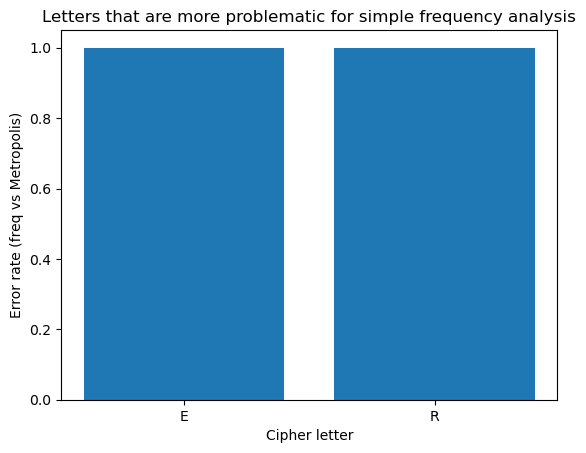

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 


Length vs positional agreement (freq vs Metropolis):
L =  100, agreement = 0.00%
L =  200, agreement = 0.00%
L =  400, agreement = 0.00%
L =  800, agreement = 0.00%
L = 1944, agreement = 0.00%


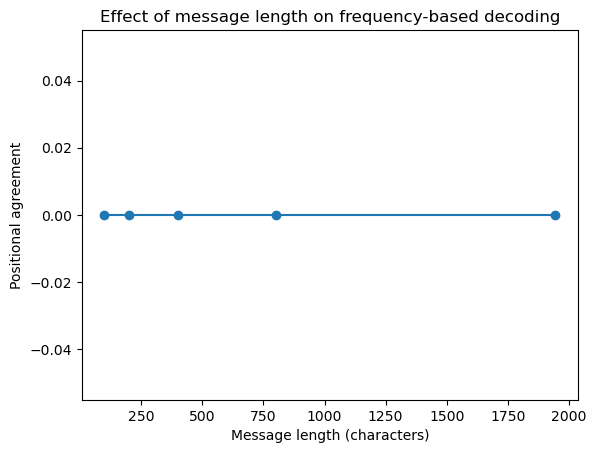


Letter probability vs success probability for the simple method:
E: P(c) ~ 0.001,  P(correct|c) ~ 0.000
R: P(c) ~ 0.001,  P(correct|c) ~ 0.000


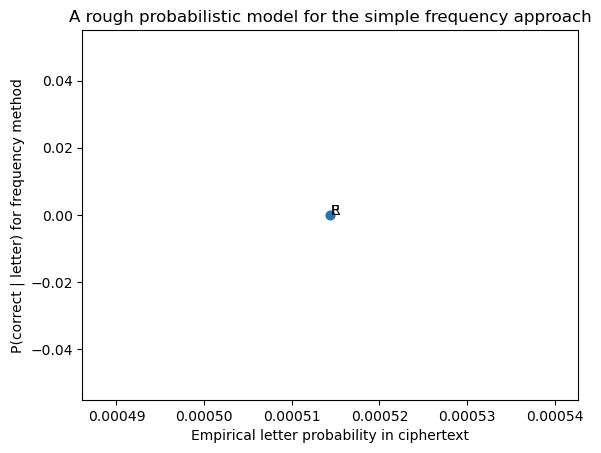

In [42]:
# extra analysis for Q8 – keep the original Part 8 code as it is,
# and just run this cell underneath.

import matplotlib.pyplot as plt

# ------------------------
# 1) per-letter behaviour
# ------------------------

# for each cipher letter, see how often freq and Metropolis agree / disagree
def per_letter_stats(ciphertext, decoded_freq, decoded_metro):
    stats = {}
    for c in character_list:
        stats[c] = {
            "count": 0,
            "same": 0,
            "diff": 0
        }

    n = min(len(ciphertext), len(decoded_freq), len(decoded_metro))
    for i in range(n):
        c = ciphertext[i]
        f = decoded_freq[i]
        m = decoded_metro[i]
        stats[c]["count"] += 1
        if f == m:
            stats[c]["same"] += 1
        else:
            stats[c]["diff"] += 1

    for c in character_list:
        cnt = stats[c]["count"]
        if cnt > 0:
            stats[c]["error_rate"] = stats[c]["diff"] / cnt
        else:
            stats[c]["error_rate"] = None
    return stats


letter_stats = per_letter_stats(ciphertext, decoded_freq, decoded_metro)

letters = []
error_rates = []
counts = []

for c in character_list:
    if letter_stats[c]["count"] > 0 and letter_stats[c]["error_rate"] is not None:
        letters.append(c)
        error_rates.append(letter_stats[c]["error_rate"])
        counts.append(letter_stats[c]["count"])

print("Per-letter error rates (simple frequency vs Metropolis):")
for c, er, cnt in zip(letters, error_rates, counts):
    print(f"{c}: error_rate = {er:.2f}, count = {cnt}")

# bar chart: which letters are more problematic?
plt.figure()
plt.bar(range(len(letters)), error_rates)
plt.xticks(range(len(letters)), letters)
plt.xlabel("Cipher letter")
plt.ylabel("Error rate (freq vs Metropolis)")
plt.title("Letters that are more problematic for simple frequency analysis")
plt.show()


# ----------------------------------------
# 2) dependence on message length (prefixes)
# ----------------------------------------

lengths = [100, 200, 400, 800, len(ciphertext)]
lengths = [L for L in lengths if L <= len(ciphertext)]

length_results = []

for L in lengths:
    ct_sub = ciphertext[:L]

    # simple frequency-based decode on the shorter message
    english_freqs_sub = get_frequency(moby_new)
    freq_map_sub = get_letter_map_from_frequency(ct_sub, english_freqs_sub, verbose=False)
    dec_freq_sub = decode(ct_sub, freq_map_sub)

    # Metropolis/bigram decode on the shorter message
    bigram_stats_sub = all_bigram_freqs(moby_new, character_list)
    dec_metro_sub = metropolis(ct_sub, character_list, bigram_stats_sub,
                               N=20000, T=1.0, verbose=False)

    agree_sub = positional_overlap(dec_freq_sub, dec_metro_sub)
    length_results.append((L, agree_sub))

print("\nLength vs positional agreement (freq vs Metropolis):")
for L, a in length_results:
    print(f"L = {L:4d}, agreement = {a*100:.2f}%")

plt.figure()
plt.plot([x[0] for x in length_results],
         [x[1] for x in length_results],
         marker="o")
plt.xlabel("Message length (characters)")
plt.ylabel("Positional agreement")
plt.title("Effect of message length on frequency-based decoding")
plt.show()


# ----------------------------------------
# 3) a rough probabilistic picture
#    P(correct | letter) vs P(letter)
# ----------------------------------------

total_len = len(ciphertext)

letter_probs = []
success_probs = []
used_letters = []

for c in character_list:
    cnt = letter_stats.get(c, {}).get("count", 0)
    er = letter_stats.get(c, {}).get("error_rate", None)
    if cnt > 0 and er is not None:
        p_c = cnt / total_len                 # empirical P(c)
        p_success = 1.0 - er                  # empirical P(correct | c)
        used_letters.append(c)
        letter_probs.append(p_c)
        success_probs.append(p_success)

print("\nLetter probability vs success probability for the simple method:")
for c, p_c, p_s in zip(used_letters, letter_probs, success_probs):
    print(f"{c}: P(c) ~ {p_c:.3f},  P(correct|c) ~ {p_s:.3f}")

plt.figure()
plt.scatter(letter_probs, success_probs)
for c, x, y in zip(used_letters, letter_probs, success_probs):
    plt.text(x, y, c)

plt.xlabel("Empirical letter probability in ciphertext")
plt.ylabel("P(correct | letter) for frequency method")
plt.title("A rough probabilistic model for the simple frequency approach")
plt.show()


In [43]:
s1 = score(ciphertext, all_bigram_freqs_dicts)
s2 = score(swap_of_char(ciphertext, "A", "B"), all_bigram_freqs_dicts)
print(s1, s2)


-10928.39504376942 -11319.893038950917


<a id="subsec4.3"></a>
#### Analysis through graphical representation

Looking back at the Metropolis Algorithm, and analysing its progress over time, there are many different quantities that factor into its effectiveness. Here, we will look at extracting these quantities from the Metropolis function and analysing them in different ways.

One way we can do this is using graphical representation. For example: by inputing different values for the temperature T into this function, we can plot multiple lines on a single graph. And defining our axes as the number of steps N against values of the score function $S(m)$, allows for an easy comparison showing how the algorithm's effectiveness is impacted by certain quantities.

After exploring several of these quantities and their behaviours, we will analyse and compare them in further detail through experimenting with numerous ideas.

**Here are the three quantities we are extracting from the Metropolis Algorithm:**
* The Score Function $S(m)$,
* The Temperature Parameter $T$,
* The Iteration Count $N$,

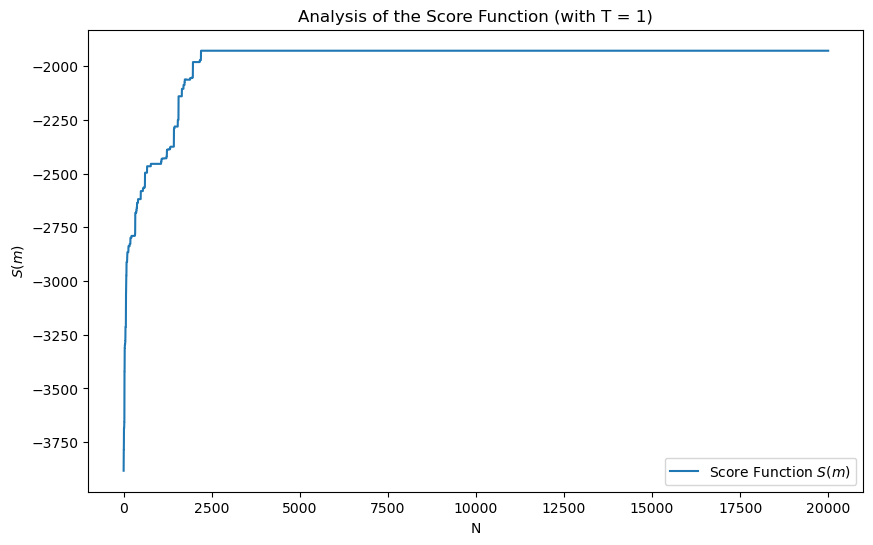

In [37]:
# Collecting the Score Function data needed for the graphs:
y_values = score_history
x_values = list(range(len(y_values)))


# Size of the figure
plt.figure(figsize =  (10, 6))

# Plot the graph
plt.plot(x_values, y_values, label = "Score Function $S(m)$")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Score Function (with T = 1)")
plt.legend()
plt.show()

* Talk about the general shape of the graph
     * Greater Score / lower N = 'worse English/decoding' (between 0 and 1000?)
     * Lower score / greater N = 'better English/decoding' (between 3000 and 20000)

     * Between 0 and 3000 - the algorithm is
* What does the plateau show?
     * The algorithm has finshed decoding the messsage
* General thoughts / analysis and mini conclusion
     * The greater the input N, the better the decoded result (better meaning 'more proper' English.
     * With this coded message in particular, the number of steps used could be shortened as by around N = 3000, the value of $S(m)$ is forever constant

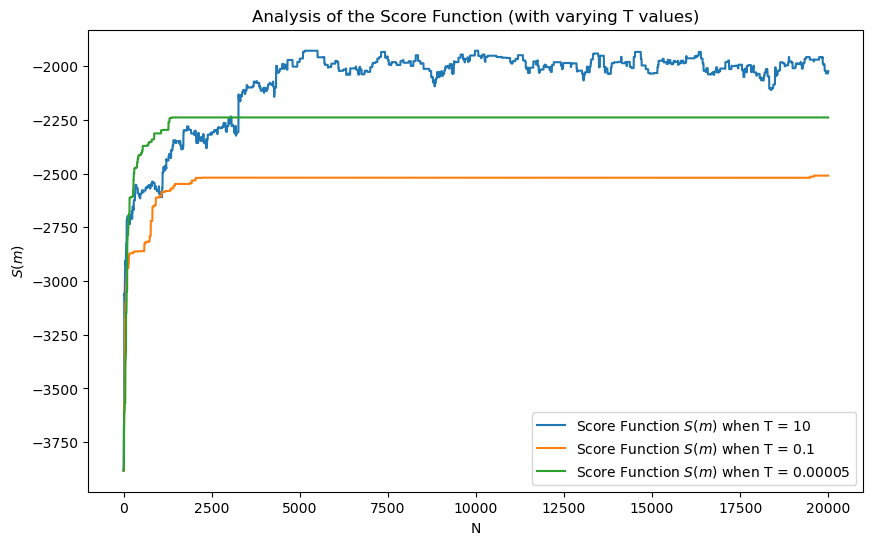

In [38]:
# NOW WE CREATE 2 COMPARISON GRAPHS:

# TEMPERATURE:
# T = 10:
final_text, T10_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 10, verbose = False)
# T = 0.1:
final_text, T01_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 0.1, verbose = False)
# T = SMALLEST CASE:
final_text, Tsmall_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 0.00005, verbose = False)


# Size of the figure
plt.figure(figsize = (10, 6))

# Plot the graph
plt.plot(x_values, T10_score_history, label = "Score Function $S(m)$ when T = 10")
plt.plot(x_values, T01_score_history, label = "Score Function $S(m)$ when T = 0.1")
plt.plot(x_values, Tsmall_score_history, label = "Score Function $S(m)$ when T = 0.00005")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Score Function (with varying T values)")
plt.legend()
plt.show()

* What's the general behaviour difference between higher T values and lower ones?
     * (COMPARING MED TO LOW) A medium T value takes ever so slightly longer than a smaller T value. We can say this because the graph for T = 0.1 (the orange line) plateaus sooner (around N = 2000) compared to when T = 0.00005 (the green line) which plateaus at roughly N = 2400
     * (COMPARING BLUE TO GREEN) If a T value is too hight, we lose a lot of precision with the algorithm. We can say this because the graph for T = 10 not only has extreme variations in its score values, but also never plateaus (the algorithm never finds a complete solution. Whereas with an extremely small value, like T = 0.00005, despite it almost being negligibly small, this still gives an almost perfect decryption when inputed into our function. -- Because of this we can say that generally, the smaller the value of T, the better our results. - TMSB
* Difference in plateaus
     * T = 10, never
     * T = 0.1, sooner than the others (best optimiser)
     * T = 0.00005, almost as efficient as T = 1
* Always reference the axes
* General thoughts / analysis and mini conclusion
     * Like before, the smaller the T, the better the yield for the algorithm

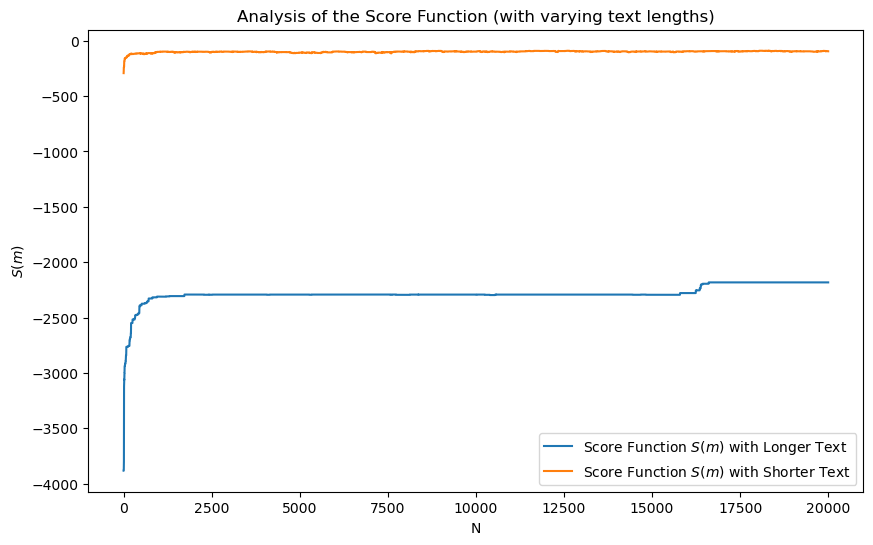

In [39]:
# LENGTH (Setting the Temperature back to T = 1):
# Long text:
final_text, long_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

# Short text:
# Reassigning our 7th coded message:
short_message = get_coded_message(6)

final_text, short_score_history = metropolis(short_message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

#########
# Note: add the lengths of each text to the labels
text_length = len(message)
#########

# Size of the figure
plt.figure(figsize = (10, 6))

# Plot the graph
plt.plot(x_values, long_score_history, label = "Score Function $S(m)$ with Longer Text")
plt.plot(x_values, short_score_history, label = "Score Function $S(m)$ with Shorter Text")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Score Function (with varying text lengths)")
plt.legend()
plt.show()

* Which text shows better results? Why do you think this happens?
     * By a quick glance, the algorithm appears to almost give up with the shorter text after only a few steps. This is shown by the orange line having next to no variations in its score values (it increase for around 100 steps, then plateaus instantly
     * Whereas with a longer text, we can clearly see (between 0 and 3500 (ish)) that the algorithm is attempting to decode the message
* Plateau differences
     * Shorter text - plateus almost instantly
     * Longer text - plateaus after 3500 ish steps
* Any other differences?
     * Shorter - Score values are extremely larger for the short text, and overall don't vary much at all (bounded between (0, -300))
     * Longer - Much lower Score values, overall bounded between (-1800, -4000)

* Thoughts, analysis, conclusion.
     * Since these two lines are so vastly different, we could try normalising our score values by diving them by the lenght of each message. Allowing us to more confidently compare the differences between these lines.

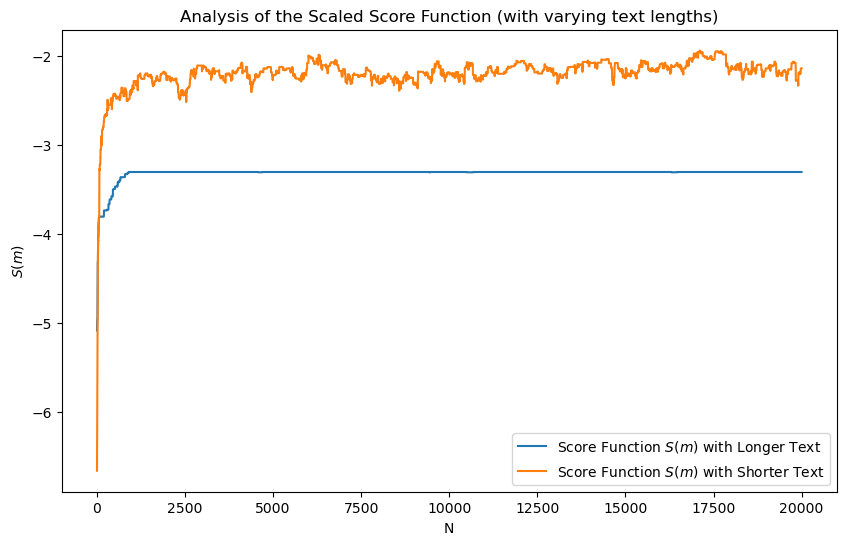

In [40]:
# Since the Score Function for the shorter text plots a graph with a greater score value 
# compared to the long text, we need to adjust the scaling for these values:
plt.figure(figsize = (10, 6))

# LENGTH (Setting the Temperature back to T = 1):
# LONG TEXT
final_text, long_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

normalized_long = [score / len(message) for score in long_score_history]
plt.plot(normalized_long, label = "Score Function $S(m)$ with Longer Text")

# SHORT
final_text, short_score_history = metropolis(short_message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

normalized_short = [score / len(short_message) for score in short_score_history]
plt.plot(normalized_short, label = "Score Function $S(m)$ with Shorter Text")


# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Scaled Score Function (with varying text lengths)")
plt.legend()
plt.show()

* Why did you scale the values? What difference does this make?
     * The score values are dependent on the number of characters in the text because score is calculated by summing the probabilities of every character pair in the message, making a longer text have a much larger total score purely because it has more characters. This is why our Score values are so vastly different. This means we need to scale our values down for each message lenght we plot a graph for. (A longer message sums more terms, resulting in a score with a much larger magnitude than a shorter message)

* Does this help / change our opinions?
     * Because of this normalistion, we can see even more clearly just how much this algorithm is dependent on message lenght.
     * With a longer message - the graph is varying in score a lot between N = 0 and N = 3500, just like before
     * However, with a shorter message, we can see clearly now that the graph never plateaus, the variations continue to occur with every step, showing that the algorithm cannot fully decode this short message
* Plateaus, values, thoughts, analysis, conclusion.
     * Thus, longer messages are easier to decode with the Metropolis algorithm because the bigrams are easier to find, whereas with the shorter messages, the probability of finding a specific bigram is even lower, hence why the algorithm continues to struggle no matter how great the value of N.

In [41]:
## Make a simulated anealing graph



* Overall analysis & comparison of the graphs.
* Overall thoughts - how it all ties together - create the fluency

* Running more steps N helps yield - same for higher T values - algorithm achieves almost correct English (closer to English than gibberish)
* How does the Score generally depends/ is affected by length, temp, steps and any other factors
* Can this help with choosing a suitable T for each coded message? How can this analysis help decode all remaining messages? - As well as choosing N

<a id="results"></a> 
## <u>Results

* Final decoded messages with correct punctuation (and comparison to original message)
* Which method(s) did you use (from questions 2-6)? And why?
* How were these method(s) improved?

<a id="con"></a>
## <u>Conclusion

* General conclusion about the whole project, nothing too long

<a id="bib"></a> 
## <u>Bibliography

(1) Uses of Cryptography: https://medium.com/@prashanthreddyt1234/real-life-applications-of-cryptography-162ddf2e917d
(2) Large sample english text: http://www.gutenberg.org/files/2701/2701-0.txt
(3) The Adventure of the Dancing Men: https://sherlock-holm.es/stories/html/danc.html
(4) Definition of Statistical Physics:  https://www.nature.com/research-intelligence/nri-topic-summaries/statistical-physics-and-message-passing-inference-micro-4406
(5) The Metropolis Algorithm: https://www.sciencedirect.com/topics/computer-science/metropolis-algorithm